In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 14a

## Sequential Model using ionosphere putting it together

1. Monitor validation set as well as training set
2. L2 Regularization
3. Dropouts
4. Batch Norm
5. Early stopping

<img src='../../prasami_images/prasami_color_tutorials_small.png' style = 'width:400px;' alt="By Pramod Sharma : pramod.sharma@prasami.com" align="left"/>

In [2]:
# Lets import some libraries
from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder

import tensorflow as tf

from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix

%matplotlib inline

I0000 00:00:1778583860.399973  121114 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Some basic parameters

inpDir = Path('../../input') # location where input data is stored
outDir = Path('../output') # location to store outputs
modelDir = Path('../models')
logDir = Path('../logs')
subDir = 'ionosphere'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
tf.random.set_seed(RANDOM_STATE) # setting for Tensorflow as well


EPOCHS = 100         # number of epochs
ALPHA = 0.001        # learning rate
WEIGHT_DECAY = 1e-4  # Weight decay
BATCH_SIZE = 16      # other sizes leave last batch partial

TRAIN_SIZE = int(BATCH_SIZE*18)

PATIENCE = 20
LR_PATIENCE = 5
LR_FACTOR = 0.1

# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,15),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.brg

plt.rcParams.update(params) # update rcParams

In [4]:
physical_devices = tf.config.list_physical_devices('GPU') 

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [5]:
(modelDir / subDir).mkdir(parents=True, exist_ok=True)

## Load Data

### Data Set Information:

This radar data was collected by a system in Goose Bay, Labrador. This system consists of a phased array of 16 high-frequency antennas with a total transmitted power on the order of 6.4 kilowatts. See the paper for more details. The targets were free electrons in the ionosphere. "Good" radar returns are those showing evidence of some type of structure in the ionosphere. "Bad" returns are those that do not; their signals pass through the ionosphere.

Received signals were processed using an autocorrelation function whose arguments are the time of a pulse and the pulse number. There were 17 pulse numbers for the Goose Bay system. Instances in this database are described by 2 attributes per pulse number, corresponding to the complex values returned by the function resulting from the complex electromagnetic signal.

Attribute Information:

-- All 34 are continuous
-- The 35th attribute is either "good" or "bad" according to the definition summarized above. This is a binary classification task.

We will model this as two class.

In [6]:
data_df = pd.read_csv(inpDir/subDir/'ionosphere.data', header = None)
data_df.shape

(351, 35)

In [7]:
data_df.head()

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,1,0,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,g
1,1,0,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,b
2,1,0,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,g
3,1,0,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,b
4,1,0,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,g


In [8]:
X = data_df.drop(data_df.columns[-1], axis = 1).to_numpy()

y = data_df[data_df.columns[-1]].to_numpy()

In [9]:
X_train, X_test, y_train, y_test = train_test_split( X, y,
                                                   train_size = TRAIN_SIZE,
                                                   stratify=y,
                                                   random_state=RANDOM_STATE)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((288, 34), (63, 34), (288,), (63,))

In [10]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)

y_test = le.transform(y_test)

In [11]:
class_name = list(le.classes_)
class_name

['b', 'g']

In [12]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

## Converting to Datasets

In [13]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train,y_train))
test_ds = tf.data.Dataset.from_tensor_slices((X_test,y_test))

I0000 00:00:1778583862.000074  121114 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4135 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [14]:
## Optimize for performance

train_ds = train_ds.cache()  # Cache first
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

test_ds = test_ds.cache()
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [15]:
# Shuffle and batch the dataset
train_ds = train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE)
test_ds = test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)

In [16]:
for features, labels in train_ds.take(1):
    print (features.shape, labels.shape)

(16, 34) (16,)


In [17]:
## Some model functions

initalizer = tf.keras.initializers.GlorotUniform(seed = RANDOM_STATE)

optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA) # using Adam optimizer

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy( from_logits = True)

model1 = tf.keras.models.Sequential([
    
    tf.keras.layers.InputLayer( shape =(34,)  ),
    
    tf.keras.layers.Dense (26,
                           activation = tf.keras.activations.relu,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.Dense (18,
                           activation = tf.keras.activations.relu,
                           kernel_initializer = initalizer),

   tf.keras.layers.Dense (10,
                           activation = tf.keras.activations.relu,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.Dense (2),
    
])

In [18]:
model1.compile(optimizer=optimizer,
               loss = loss_fn,
               metrics= ['accuracy'])



In [19]:
history = model1.fit( train_ds,
                    epochs=EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data=test_ds,
                    verbose = 2)

Epoch 1/100


I0000 00:00:1778583864.236424  121212 service.cc:153] XLA service 0x791fc8031ec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778583864.236457  121212 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1778583864.253869  121212 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778583864.366995  121212 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1778583864.373023  121212 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1498__.12
I0000 00:00:1778583866.135245  121212 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/18 - 4s - 211ms/step - accuracy: 0.7500 - loss: 0.6484 - val_accuracy: 0.7302 - val_loss: 0.6475
Epoch 2/100
18/18 - 0s - 2ms/step - accuracy: 0.8125 - loss: 0.5494 - val_accuracy: 0.7937 - val_loss: 0.5738
Epoch 3/100
18/18 - 0s - 2ms/step - accuracy: 0.8438 - loss: 0.4787 - val_accuracy: 0.8254 - val_loss: 0.5139
Epoch 4/100
18/18 - 0s - 2ms/step - accuracy: 0.8785 - loss: 0.4197 - val_accuracy: 0.8413 - val_loss: 0.4570
Epoch 5/100
18/18 - 0s - 2ms/step - accuracy: 0.8819 - loss: 0.3703 - val_accuracy: 0.8413 - val_loss: 0.4133
Epoch 6/100
18/18 - 0s - 2ms/step - accuracy: 0.8924 - loss: 0.3288 - val_accuracy: 0.8571 - val_loss: 0.3658
Epoch 7/100
18/18 - 0s - 2ms/step - accuracy: 0.9062 - loss: 0.2916 - val_accuracy: 0.8571 - val_loss: 0.3435
Epoch 8/100
18/18 - 0s - 2ms/step - accuracy: 0.9236 - loss: 0.2603 - val_accuracy: 0.8571 - val_loss: 0.3052
Epoch 9/100
18/18 - 0s - 2ms/step - accuracy: 0.9271 - loss: 0.2349 - val_accuracy: 0.8571 - val_loss: 0.2885
Epoch 10/100
18/18 -

In [20]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 26)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │           486 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,826 (18.86 KB)

 Trainable params: 1,608 (6.28 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,218 (12.57 KB)

In [21]:
hist_df = pd.DataFrame(history.history)
hist_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.750000,0.648399,0.730159,0.647518
1,0.812500,0.549401,0.793651,0.573837
2,0.843750,0.478749,0.825397,0.513898
3,0.878472,0.419704,0.841270,0.457041
4,0.881944,0.370318,0.841270,0.413336


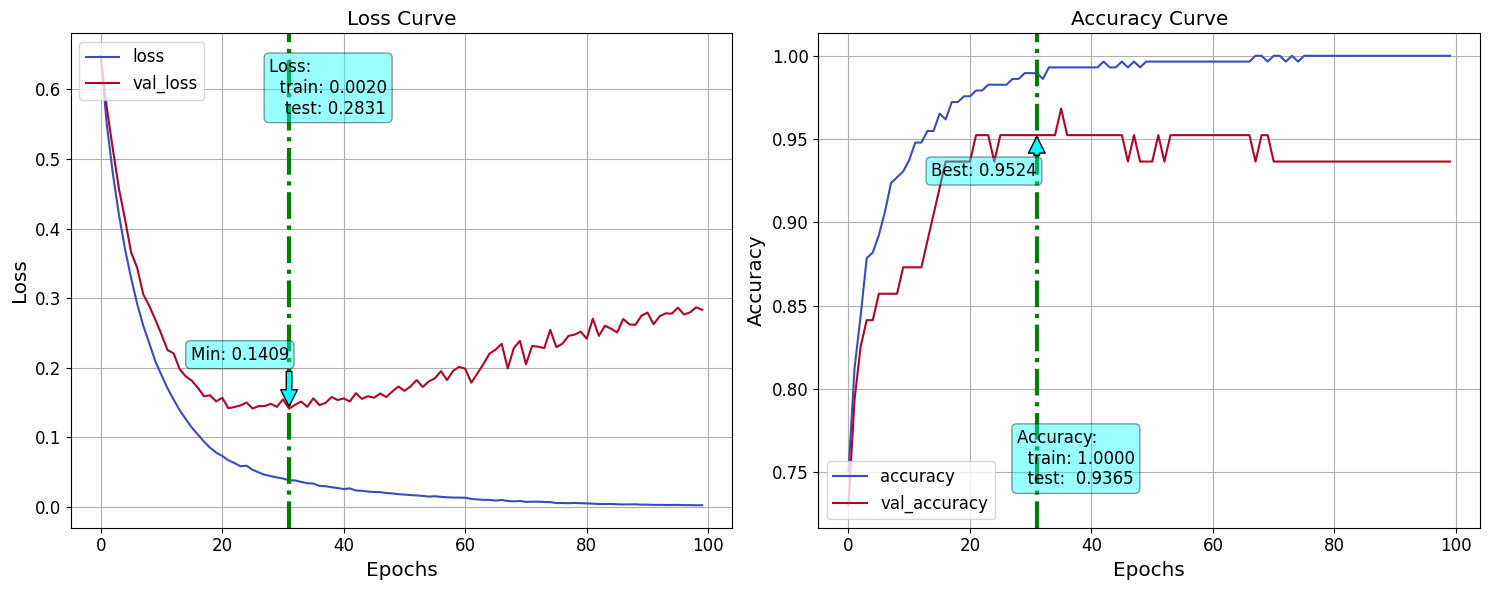

In [22]:
fn_plot_tf_hist(hist_df)

In [23]:
hist_df[hist_df['val_loss'] == hist_df['val_loss'].min()]

,accuracy,loss,val_accuracy,val_loss
31,0.989583,0.037908,0.952381,0.140914


In [24]:
proba_model1 = tf.keras.Sequential([model1,
                                   tf.keras.layers.Softmax()])

y_pred = proba_model1(X_test)

In [25]:
class_name

['b', 'g']

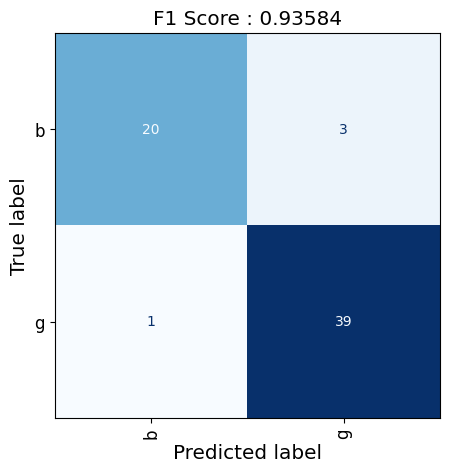

In [26]:
fn_plot_confusion_matrix(y_test, y_pred.numpy().argmax(axis = 1), labels=class_name)

## L2 Regularizer

L2 regularization (also called weight decay) adds a penalty term to the loss function:

**Loss = original_loss + $\lambda \cdot \sum(w^2)$**

This encourages weights to be small, preventing any single feature from dominating and reducing overfitting.

In [27]:
## Some model functions

initalizer = tf.keras.initializers.GlorotUniform(seed = RANDOM_STATE)

optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA) # using Adam optimizer

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy( from_logits = True)

regularizer = tf.keras.regularizers.L2(0.05)

model2 = tf.keras.models.Sequential([
    
    tf.keras.layers.InputLayer( shape =( 34, ) ),

    tf.keras.layers.Dense (26,
                           activation = tf.keras.activations.relu,
                           kernel_initializer = initalizer,
                           kernel_regularizer = regularizer),   # ---- add L2 Regularizer
    
    tf.keras.layers.Dense (18,
                           activation = tf.keras.activations.relu,
                           kernel_initializer = initalizer,
                           kernel_regularizer = regularizer),   # ---- add L2 Regularizer

   tf.keras.layers.Dense (10,
                           activation = tf.keras.activations.relu,
                           kernel_initializer = initalizer,
                           kernel_regularizer = regularizer),   # ---- add L2 Regularizer
    
    tf.keras.layers.Dense (2),
    
])

model2.compile(optimizer=optimizer,
               loss = loss_fn,
               metrics= ['accuracy'])


history = model2.fit(train_ds,
                    epochs=EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data=test_ds,
                    verbose = 2)

hist_df = pd.DataFrame(history.history)

Epoch 1/100


I0000 00:00:1778583871.937210  121211 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_14658__.16


18/18 - 3s - 152ms/step - accuracy: 0.3646 - loss: 3.7202 - val_accuracy: 0.4921 - val_loss: 3.3817
Epoch 2/100
18/18 - 0s - 2ms/step - accuracy: 0.6562 - loss: 3.2223 - val_accuracy: 0.8413 - val_loss: 3.0016
Epoch 3/100
18/18 - 0s - 2ms/step - accuracy: 0.8507 - loss: 2.8727 - val_accuracy: 0.8730 - val_loss: 2.6944
Epoch 4/100
18/18 - 0s - 2ms/step - accuracy: 0.8924 - loss: 2.5728 - val_accuracy: 0.9048 - val_loss: 2.4245
Epoch 5/100
18/18 - 0s - 2ms/step - accuracy: 0.9028 - loss: 2.3060 - val_accuracy: 0.8730 - val_loss: 2.1860
Epoch 6/100
18/18 - 0s - 2ms/step - accuracy: 0.9132 - loss: 2.0668 - val_accuracy: 0.8730 - val_loss: 1.9715
Epoch 7/100
18/18 - 0s - 2ms/step - accuracy: 0.9201 - loss: 1.8540 - val_accuracy: 0.8730 - val_loss: 1.7792
Epoch 8/100
18/18 - 0s - 2ms/step - accuracy: 0.9271 - loss: 1.6668 - val_accuracy: 0.8889 - val_loss: 1.6068
Epoch 9/100
18/18 - 0s - 2ms/step - accuracy: 0.9306 - loss: 1.5024 - val_accuracy: 0.8889 - val_loss: 1.4599
Epoch 10/100
18/18 -

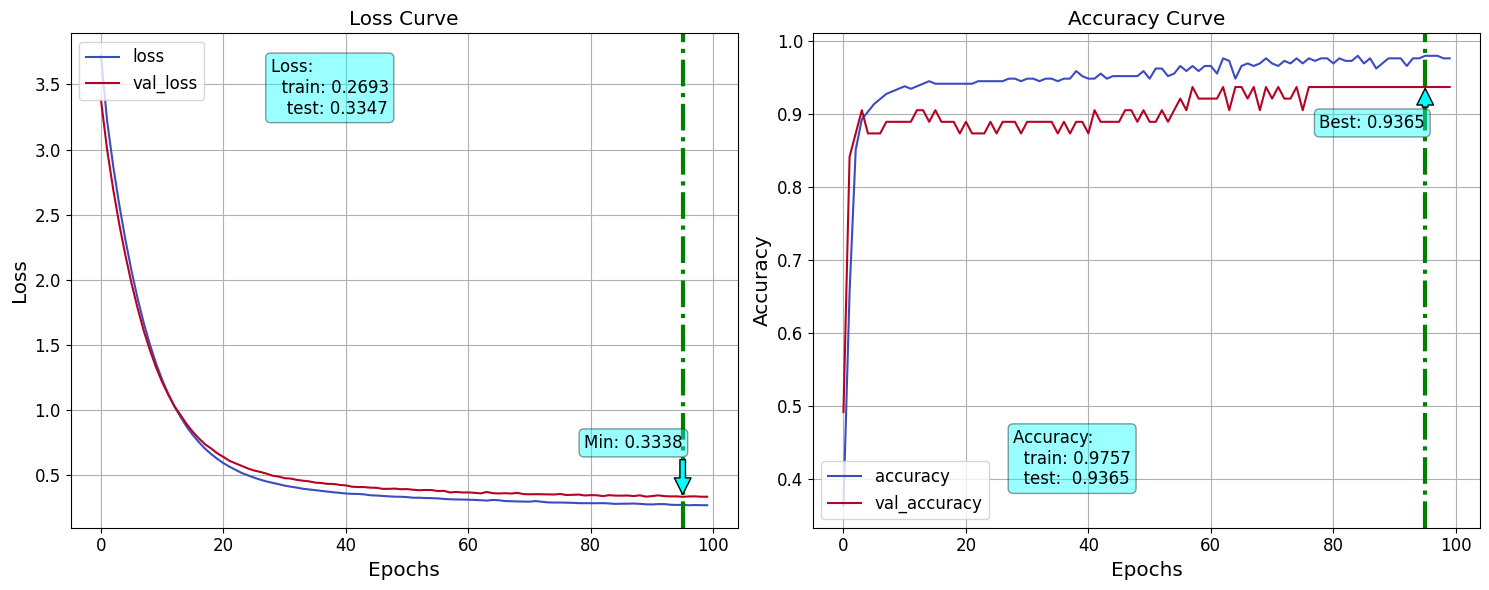

In [28]:
fn_plot_tf_hist(hist_df)

## Batch Normalization
- Normalizes layer outputs to have mean ~0, variance ~1
- Allows higher learning rates
- Reduces internal covariate shift
- Has a slight regularization effect

In [29]:
## Some model functions

initalizer = tf.keras.initializers.GlorotUniform(seed = RANDOM_STATE)

optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA) # using Adam optimizer

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy( from_logits = True)

model3 = tf.keras.models.Sequential([
    
    tf.keras.layers.InputLayer( shape =(34,)  ),
    
    tf.keras.layers.Dense (26,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    
    tf.keras.layers.Dense (18,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    tf.keras.layers.Dense (10,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    tf.keras.layers.Dense (2),
    
])


model3.compile(optimizer=optimizer,
               loss = loss_fn,
               metrics= ['accuracy'])


history = model3.fit(train_ds, 
                     epochs=EPOCHS,
                     batch_size = BATCH_SIZE,
                     validation_data=test_ds,
                     verbose = 2)

hist_df = pd.DataFrame(history.history)

Epoch 1/100


I0000 00:00:1778583878.761475  121214 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_28974__.30


18/18 - 4s - 233ms/step - accuracy: 0.6944 - loss: 0.6959 - val_accuracy: 0.5714 - val_loss: 0.6371
Epoch 2/100
18/18 - 0s - 2ms/step - accuracy: 0.7535 - loss: 0.4952 - val_accuracy: 0.7937 - val_loss: 0.5211
Epoch 3/100
18/18 - 0s - 2ms/step - accuracy: 0.8368 - loss: 0.4292 - val_accuracy: 0.8889 - val_loss: 0.4294
Epoch 4/100
18/18 - 0s - 2ms/step - accuracy: 0.8507 - loss: 0.3729 - val_accuracy: 0.9048 - val_loss: 0.3740
Epoch 5/100
18/18 - 0s - 2ms/step - accuracy: 0.8785 - loss: 0.3126 - val_accuracy: 0.9524 - val_loss: 0.3352
Epoch 6/100
18/18 - 0s - 2ms/step - accuracy: 0.8715 - loss: 0.3186 - val_accuracy: 0.9365 - val_loss: 0.3023
Epoch 7/100
18/18 - 0s - 2ms/step - accuracy: 0.8715 - loss: 0.2983 - val_accuracy: 0.9365 - val_loss: 0.2761
Epoch 8/100
18/18 - 0s - 2ms/step - accuracy: 0.9132 - loss: 0.2558 - val_accuracy: 0.9365 - val_loss: 0.2491
Epoch 9/100
18/18 - 0s - 2ms/step - accuracy: 0.9062 - loss: 0.2447 - val_accuracy: 0.9365 - val_loss: 0.2285
Epoch 10/100
18/18 -

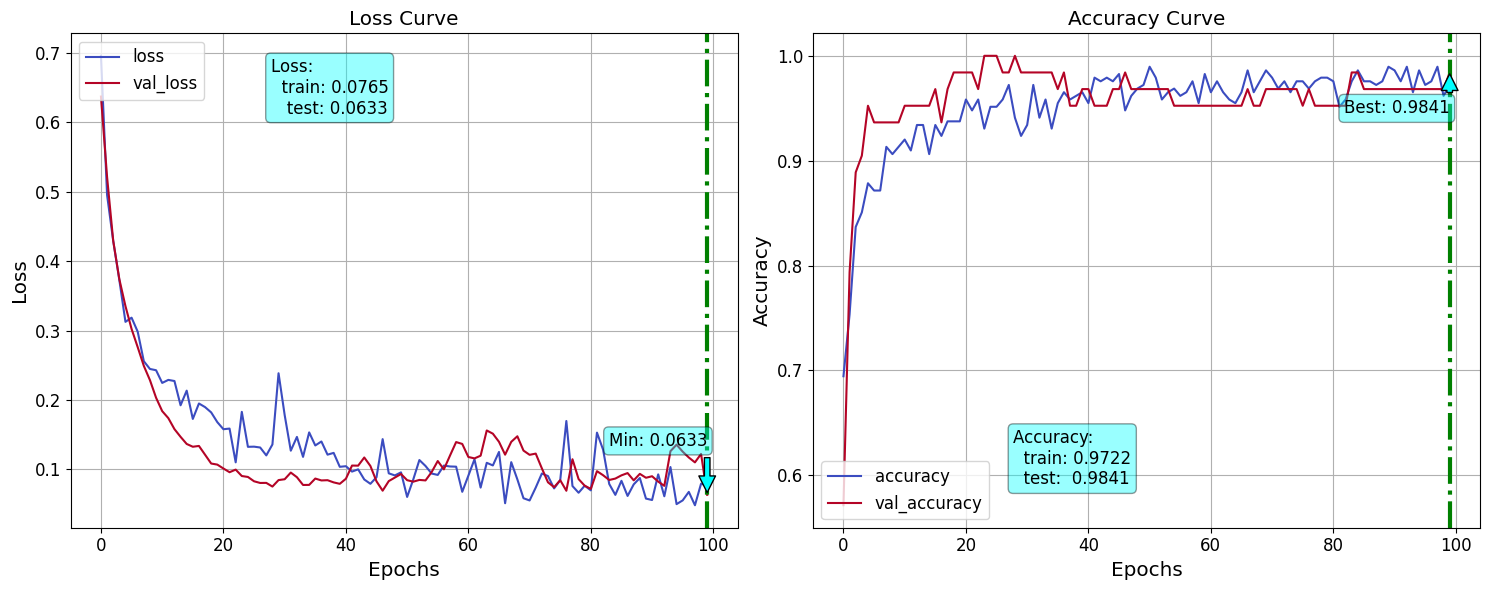

In [30]:
fn_plot_tf_hist(hist_df)

In [31]:
hist_df[hist_df['val_loss'] == hist_df['val_loss'].min()]

,accuracy,loss,val_accuracy,val_loss
99,0.972222,0.076494,0.984127,0.063272


## DROP OUTS

In [32]:
rate1 = 0.2
rate2 = 0.3
rate3 = 0.4

## Some model functions

initalizer = tf.keras.initializers.GlorotUniform(seed = RANDOM_STATE)

optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA) # using Adam optimizer

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy( from_logits = True)

model4 = tf.keras.models.Sequential([
    
    tf.keras.layers.InputLayer( shape =(34,)  ),
    
    tf.keras.layers.Dense (26,
                           activation = 'relu',
                           kernel_initializer = initalizer),
    
    tf.keras.layers.Dropout(rate1 , seed = RANDOM_STATE),
    
    tf.keras.layers.Dense (18,
                           activation = 'relu',
                           kernel_initializer = initalizer),
    
    tf.keras.layers.Dropout(rate2 , seed = RANDOM_STATE),

    tf.keras.layers.Dense (10,
                           activation = 'relu',
                           kernel_initializer = initalizer),
    
    tf.keras.layers.Dropout(rate3 , seed = RANDOM_STATE),
    
    tf.keras.layers.Dense (2),
    
])


model4.compile(optimizer=optimizer,
               loss = loss_fn,
               metrics= ['accuracy'])


history = model4.fit(train_ds,
                     epochs=EPOCHS,
                     batch_size = BATCH_SIZE,
                     validation_data=test_ds,
                     verbose = 2)

hist_df = pd.DataFrame(history.history)

Epoch 1/100


I0000 00:00:1778583886.040742  121213 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_42312__.15


18/18 - 3s - 177ms/step - accuracy: 0.3819 - loss: 0.7905 - val_accuracy: 0.3968 - val_loss: 0.6816
Epoch 2/100
18/18 - 0s - 2ms/step - accuracy: 0.4618 - loss: 0.7240 - val_accuracy: 0.7937 - val_loss: 0.6324
Epoch 3/100
18/18 - 0s - 2ms/step - accuracy: 0.6354 - loss: 0.6480 - val_accuracy: 0.8095 - val_loss: 0.6051
Epoch 4/100
18/18 - 0s - 2ms/step - accuracy: 0.6528 - loss: 0.6361 - val_accuracy: 0.8254 - val_loss: 0.5832
Epoch 5/100
18/18 - 0s - 2ms/step - accuracy: 0.7639 - loss: 0.5859 - val_accuracy: 0.8571 - val_loss: 0.5574
Epoch 6/100
18/18 - 0s - 2ms/step - accuracy: 0.7569 - loss: 0.5775 - val_accuracy: 0.8730 - val_loss: 0.5245
Epoch 7/100
18/18 - 0s - 2ms/step - accuracy: 0.7917 - loss: 0.5469 - val_accuracy: 0.8889 - val_loss: 0.4864
Epoch 8/100
18/18 - 0s - 2ms/step - accuracy: 0.8160 - loss: 0.4988 - val_accuracy: 0.8730 - val_loss: 0.4505
Epoch 9/100
18/18 - 0s - 2ms/step - accuracy: 0.8333 - loss: 0.4855 - val_accuracy: 0.8889 - val_loss: 0.4091
Epoch 10/100
18/18 -

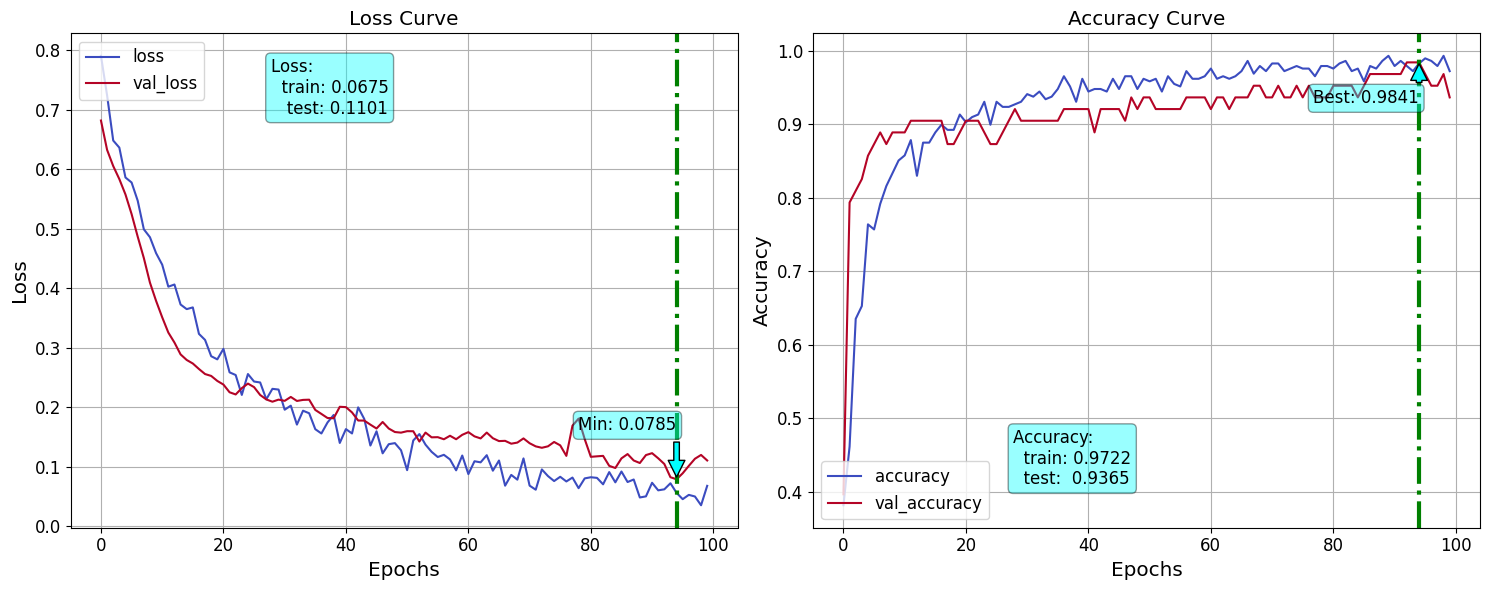

In [33]:
fn_plot_tf_hist(hist_df)

In [34]:
hist_df[hist_df['val_loss'] == hist_df['val_loss'].min()]

,accuracy,loss,val_accuracy,val_loss
94,0.982639,0.055687,0.984127,0.078522


### All In

In [35]:
rate1 = 0.05
rate2 = 0.15
rate3 = 0.25

## Some model functions

initalizer = tf.keras.initializers.GlorotUniform(seed = RANDOM_STATE)

optimizer = tf.keras.optimizers.AdamW(learning_rate=ALPHA, weight_decay=WEIGHT_DECAY) # using Adam optimizer

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy( from_logits = True)

# Suppressing regularization
#regularizer = tf.keras.regularizers.L2(0.05)
regularizer = None

model = tf.keras.models.Sequential([
    
    tf.keras.layers.InputLayer( shape =(34,)  ),
    
    tf.keras.layers.Dense (26,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    tf.keras.layers.Dropout(rate1 , seed = RANDOM_STATE),
    
    tf.keras.layers.Dense (18,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    tf.keras.layers.Dropout(rate2 , seed = RANDOM_STATE),

    tf.keras.layers.Dense (10,
                           kernel_initializer = initalizer),
    
    tf.keras.layers.BatchNormalization(),
    
    tf.keras.layers.Activation(activation='relu'),

    tf.keras.layers.Dropout(rate3 , seed = RANDOM_STATE),
    
    tf.keras.layers.Dense (2),
    
])

model.compile(optimizer=optimizer,
               loss = loss_fn,
               metrics= ['accuracy'])

In [36]:
checkpoint_filepath = modelDir / subDir / 'all_in.keras'

# Model is saved at the end of every epoch, if it's the best seen so far.
chkpt_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',
    verbose = 2,
    save_best_only=True
)

es_callback = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience=PATIENCE,
    mode='auto',
    verbose = 2,
    baseline =None,
    restore_best_weights=True)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=2,
    mode='auto',
    min_lr=0.00001)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logDir)

In [37]:
history = model.fit(train_ds, 
                    epochs = EPOCHS,
                    batch_size = BATCH_SIZE,
                    validation_data=test_ds,
                    verbose = 2,
                    callbacks = [es_callback, 
                                 chkpt_callback, 
                                 lr_callback, 
                                 tensorboard_callback])

hist_df = pd.DataFrame(history.history)

Epoch 1/100


I0000 00:00:1778583893.757012  121212 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_57013__.33



Epoch 1: val_loss improved from None to 0.73340, saving model to ../models/ionosphere/all_in.keras

Epoch 1: finished saving model to ../models/ionosphere/all_in.keras
18/18 - 5s - 276ms/step - accuracy: 0.4722 - loss: 0.9945 - val_accuracy: 0.3651 - val_loss: 0.7334 - learning_rate: 0.0010
Epoch 2/100

Epoch 2: val_loss improved from 0.73340 to 0.61782, saving model to ../models/ionosphere/all_in.keras

Epoch 2: finished saving model to ../models/ionosphere/all_in.keras
18/18 - 0s - 5ms/step - accuracy: 0.5278 - loss: 0.8371 - val_accuracy: 0.5079 - val_loss: 0.6178 - learning_rate: 0.0010
Epoch 3/100

Epoch 3: val_loss improved from 0.61782 to 0.54073, saving model to ../models/ionosphere/all_in.keras

Epoch 3: finished saving model to ../models/ionosphere/all_in.keras
18/18 - 0s - 5ms/step - accuracy: 0.5764 - loss: 0.7424 - val_accuracy: 0.7619 - val_loss: 0.5407 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: val_loss improved from 0.54073 to 0.48472, saving model to ../models/iono

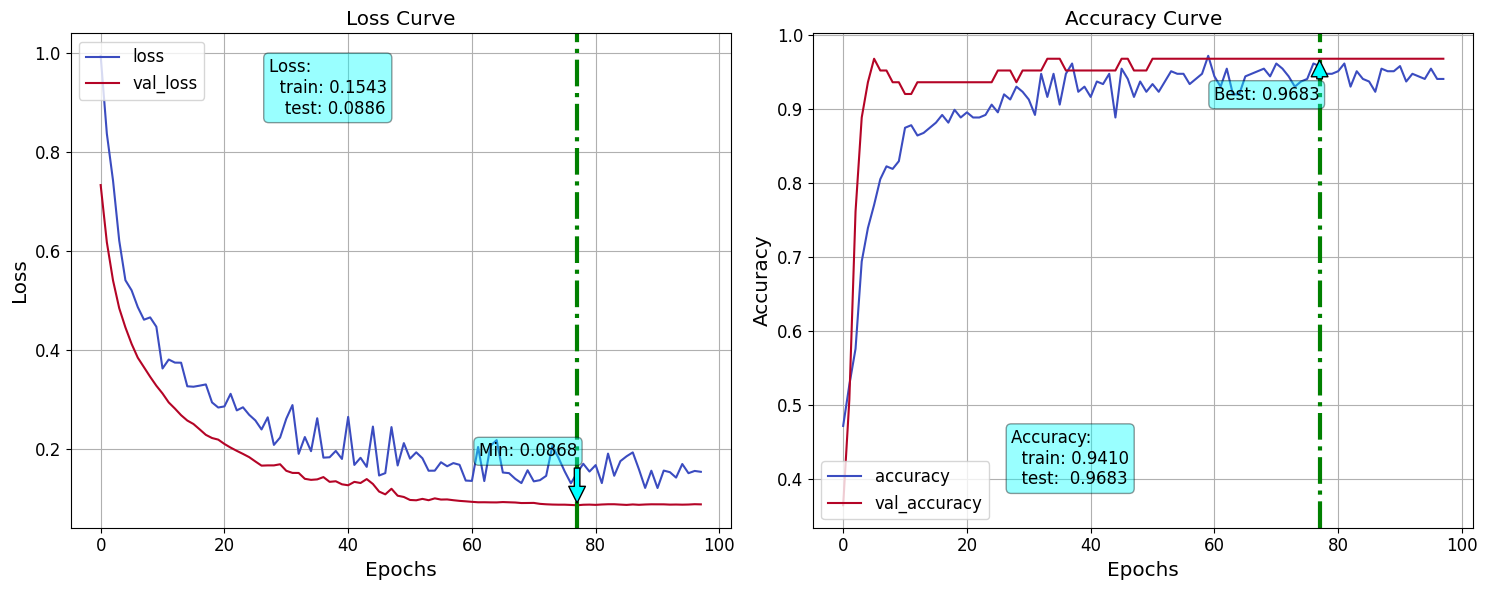

In [38]:
fn_plot_tf_hist(hist_df)

In [39]:
loss_dict = model.evaluate(test_ds, verbose=1 , return_dict=True)
loss_dict

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9683 - loss: 0.0868


{'accuracy': 0.9682539701461792, 'loss': 0.08680519461631775}

In [40]:
hist_df[hist_df['val_loss'] == hist_df['val_loss'].min()]

,accuracy,loss,val_accuracy,val_loss,learning_rate
77,0.958333,0.152239,0.968254,0.086805,0.0001


In [41]:
del model
del model1
del model2
del model3
del model4

## Save Complete Model

In [42]:
# Load the best model
model = tf.keras.models.load_model(checkpoint_filepath)

In [43]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 26)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26)             │           104 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 18)             │           486 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 18)             │            72 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,258 (20.54 KB)

 Trainable params: 1,716 (6.70 KB)

 Non-trainable params: 108 (432.00 B)

 Optimizer params: 3,434 (13.42 KB)

In [44]:
res = model.evaluate(test_ds, verbose=2, return_dict=True)

res['accuracy']

4/4 - 1s - 229ms/step - accuracy: 0.9683 - loss: 0.0868


0.9682539701461792

## Summary: Regularization Techniques Comparison

| Technique | Purpose | Key Parameter | Effect |
|-----------|---------|---------------|--------|
| L2 Regularization | Penalize large weights | $\lambda$ (lambda) | Smooths decision boundary |
| Dropout | Randomly disable neurons | dropout rate | Forces redundant learning |
| Batch Normalization | Normalize layer inputs | momentum | Faster, stable training |
| Early Stopping | Stop when val loss stops improving | patience | Prevents overfitting |
| Learning Rate Decay| Reduce when loss stops reducing | patience, LR factor | finetunes LR|

**Best Practice:** Combine techniques thoughtfully. Too much regularization = underfitting.